In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r'/content/cleaned_Customer Churn.csv')

In [ ]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from  sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler ,OrdinalEncoder,OneHotEncoder

In [ ]:
x = df.drop(['Exited'],axis=1)
y = df['Exited']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
cat_col = x.select_dtypes(include=['object']).columns
nos_col = x.select_dtypes(include=['int64','float64']).columns

nos_col

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [ ]:
cat_col

Index(['Geography', 'Gender'], dtype='object')

In [ ]:
for col in cat_col:
    print(col,' ',x[col].unique())

Geography   ['France' 'Spain' 'Germany']
Gender   ['Female' 'Male']


In [ ]:
nos_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline([
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))
])

In [ ]:
preprocessor = ColumnTransformer([
    ('num',nos_pipeline,nos_col),
    ('nom',nominal_pipeline,cat_col)
])

x_train = preprocessor.fit_transform(x_train)

x_test = preprocessor.transform(x_test)

<Axes: xlabel='Exited', ylabel='count'>

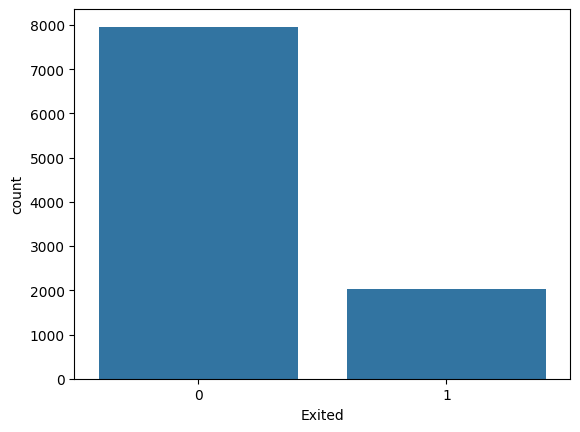

In [ ]:
sns.countplot( x='Exited',data=df)

In [ ]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

In [ ]:
y_train.value_counts(normalize=True)

,proportion
Exited,
0,0.7945
1,0.2055


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(Dense(150, activation='relu', input_dim=x_train.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(80, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(50, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(20, activation='relu'))
model.add(BatchNormalization())

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.optimizers import Adam, RMSprop, Adamax, Nadam, SGD


optimizer = Adamax(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=30,
    validation_data=(x_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8031 - loss: 0.4201 - val_accuracy: 0.7860 - val_loss: 0.4447
Epoch 2/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8035 - loss: 0.4236 - val_accuracy: 0.7815 - val_loss: 0.4460
Epoch 3/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8012 - loss: 0.4267 - val_accuracy: 0.7835 - val_loss: 0.4412
Epoch 4/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8015 - loss: 0.4157 - val_accuracy: 0.7860 - val_loss: 0.4383
Epoch 5/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7990 - loss: 0.4233 - val_accuracy: 0.7770 - val_loss: 0.4425
Epoch 6/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7989 - loss: 0.4238 - val_accuracy: 0.7760 - val_loss: 0.4431
Epoch 7/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7983 - loss: 0.4171 - val_accuracy: 0.7800 - val_loss: 0.4437
Epoch 8/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7984 - loss: 0.4204 - val_ac

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7920 - loss: 0.4345
0.7919999957084656


In [ ]:
y_pred = model.predict(x_test)

y_pred = (y_pred > 0.55)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


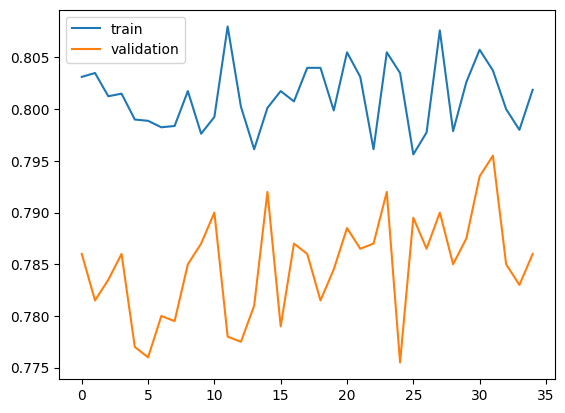

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['train','validation'])
plt.show()

In [ ]:
train_acc = history.history['accuracy'][-1]

val_acc = history.history['val_accuracy'][-1]

print(train_acc)
print(val_acc)

0.8018749952316284
0.7860000133514404


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[1342  265]
 [ 105  288]]
              precision    recall  f1-score   support

           0       0.93      0.84      0.88      1607
           1       0.52      0.73      0.61       393

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.85      0.81      0.83      2000



In [ ]:
print(y_test[:10].values)

print(y_pred[:10])

[0 0 0 0 0 0 0 1 0 0]
[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]
 [False]
 [ True]]


In [ ]:
pred_prob = model.predict(x_test[:10])

print(pred_prob)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
[[0.06297648]
 [0.02161838]
 [0.18232985]
 [0.34631154]
 [0.35857475]
 [0.01076079]
 [0.20029978]
 [0.55489534]
 [0.472106  ]
 [0.8368454 ]]


In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict(x_test)

print(roc_auc_score(y_test, y_prob))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
0.8578721275083091


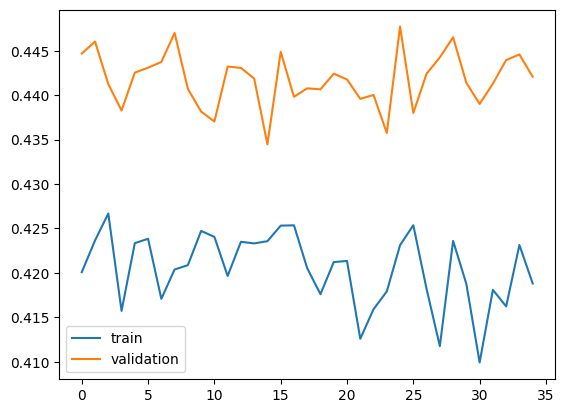

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['train','validation'])
plt.show()

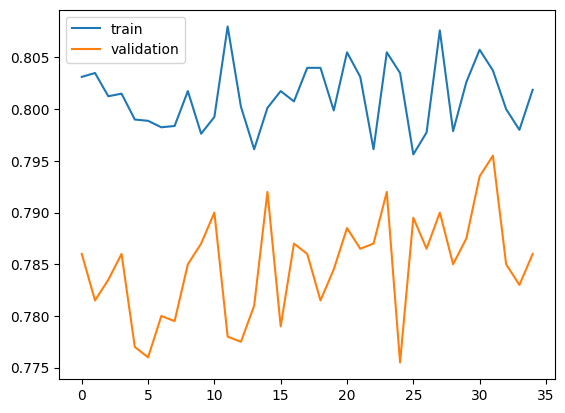

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['train','validation'])
plt.show()

In [ ]:
model.save("ann_model.keras")

In [ ]:
from google.colab import files

files.download("ann_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

In [ ]:
from google.colab import files

files.download('preprocessor.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>